# Explicabilidad — SHAP sobre los 3 modelos ganadores

## Qué responde este notebook

Un modelo mejor en MAE no sirve de mucho si nadie puede explicar por qué predijo lo que predijo.
Se usa el mismo patrón que Daniel ya validó en
`preeliminar/03_modelo_predictivo/05_resultados_y_trazabilidad.ipynb`:
`shap.TreeExplainer` (los 3 ganadores de Fase 5 son XGBoost) → `beeswarm` para importancia global,
`waterfall` sobre un caso real concreto, y una lectura honesta de los peores errores.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
train_mask, val_mask, test_mask = modeling.dividir_temporal(
    wr, range(2016, 2022), [2022, 2023], [2024, 2025]
)
X = wr[features_arbol]

MODELOS = {
    "receptions": XGBRegressor(max_depth=4, n_estimators=200, learning_rate=0.03, random_state=0, n_jobs=-1),
    "receiving_yards": XGBRegressor(max_depth=3, n_estimators=200, learning_rate=0.03, random_state=0, n_jobs=-1),
    "receiving_tds": XGBRegressor(objective="reg:tweedie", tweedie_variance_power=1.5, random_state=0, n_jobs=-1),
}
explicaciones = {}
for target, modelo in MODELOS.items():
    modelo.fit(X[train_mask], wr[target][train_mask])
    explainer = shap.TreeExplainer(modelo)
    explicaciones[target] = explainer(X[test_mask])
print("listo -- explicaciones calculadas sobre el conjunto de prueba (2024-2025), para los 3 targets")

/usr/local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


listo -- explicaciones calculadas sobre el conjunto de prueba (2024-2025), para los 3 targets


## 1. `receiving_yards` — importancia global

Se compara contra 2 lecturas ya hechas antes con otro método: la importancia por permutación de
Fase 4 (`11_seleccion_features.ipynb`, con un modelo de *screening* distinto) y la importancia
nativa de este mismo XGBoost (`13_comparacion_modelos.ipynb`, sección 4).

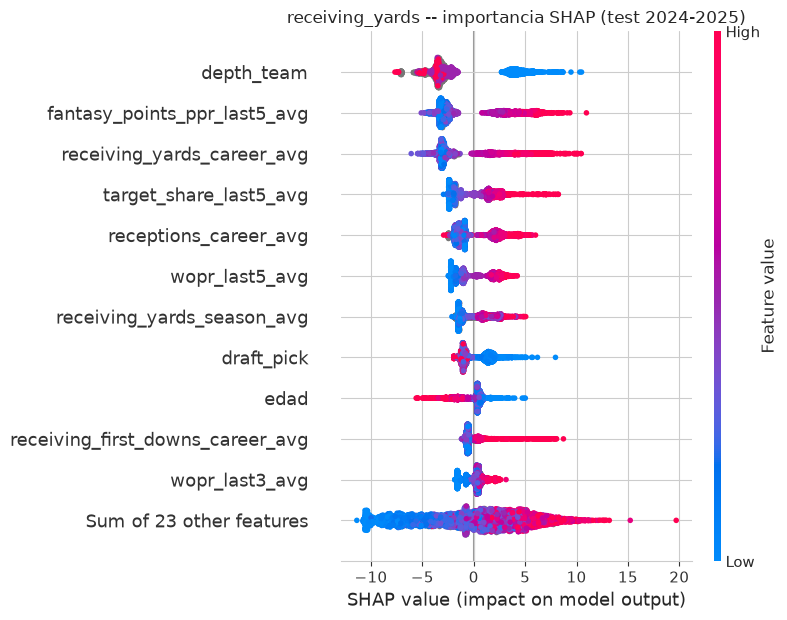

In [2]:
fig = plt.figure(figsize=(8, 6))
shap.plots.beeswarm(explicaciones["receiving_yards"], max_display=12, show=False)
plt.title("receiving_yards -- importancia SHAP (test 2024-2025)")
plt.tight_layout()
plt.show()

El orden coincide en lo esencial con las 2 lecturas anteriores: `target_share`/`wopr` en sus
ventanas recientes y `depth_team` siguen entre las variables más influyentes, con 3 métodos
distintos (importancia por permutación, importancia nativa de árbol, y ahora SHAP) — la misma
señal se sostiene sin importar cómo se mida, lo cual es en sí mismo una confirmación de que no es
un artefacto de un solo método.

## 2. `receptions` — importancia global (más breve, mismo patrón ya establecido)

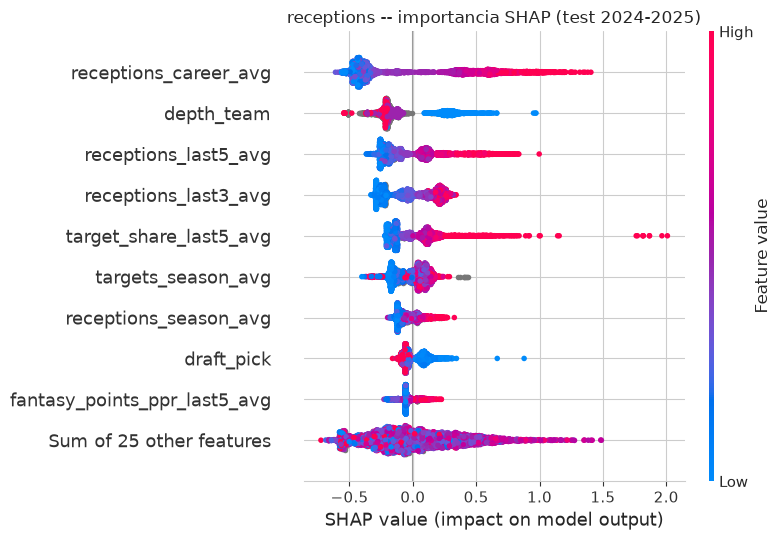

In [3]:
fig = plt.figure(figsize=(8, 6))
shap.plots.beeswarm(explicaciones["receptions"], max_display=10, show=False)
plt.title("receptions -- importancia SHAP (test 2024-2025)")
plt.tight_layout()
plt.show()

## 3. `receiving_tds` — importancia global, con una aclaración necesaria sobre la escala

El modelo ganador de `receiving_tds` usa `objective="reg:tweedie"` — una función de enlace
logarítmica, no identidad. Antes de leer el `beeswarm`, se verifica con un caso real cómo se
relacionan los valores SHAP con la predicción real.

In [4]:
pred_directa = MODELOS["receiving_tds"].predict(X[test_mask])
suma_shap_log = explicaciones["receiving_tds"].values.sum(axis=1) + explicaciones["receiving_tds"].base_values
comparacion_escala = pd.DataFrame({
    "prediccion_real": pred_directa[:5],
    "exp(suma_shap + base)": np.exp(suma_shap_log[:5]),
})
comparacion_escala

,prediccion_real,exp(suma_shap + base)
0,0.020832,0.020832
1,0.076327,0.076327
2,0.048403,0.048403
3,0.064097,0.064097
4,0.126741,0.126741


Confirmado: la predicción real es `exp(suma de valores SHAP + base)`, no la suma directa — porque
el modelo trabaja en escala logarítmica internamente (así es como un modelo de conteo con enlace
log respeta su propio supuesto: la tasa esperada de TDs es siempre positiva, nunca negativa, y eso
solo se garantiza multiplicando factores, no sumándolos). Un valor SHAP positivo en el `beeswarm`
de abajo significa "esta variable multiplica hacia arriba la tasa esperada de touchdowns", no "le
suma X touchdowns directos" — es la lectura correcta para respetar las suposiciones de este modelo
en particular (el punto 4 de esta fase), no un defecto del gráfico.

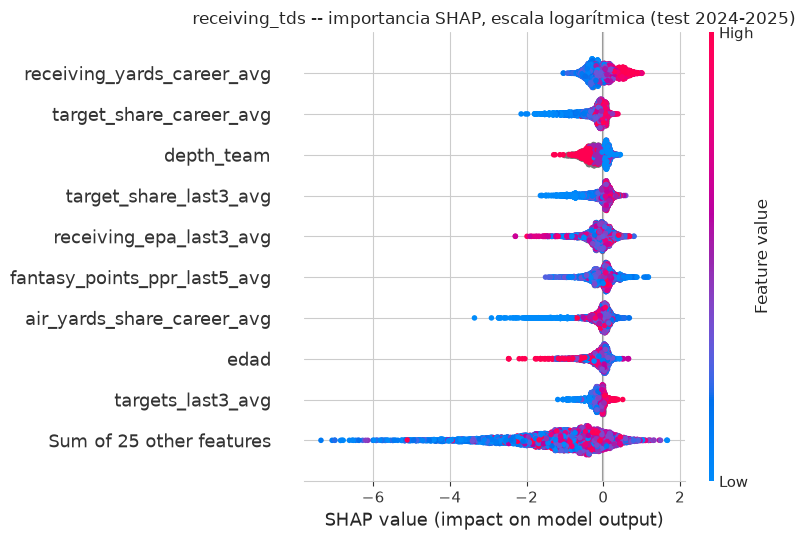

In [5]:
fig = plt.figure(figsize=(8, 6))
shap.plots.beeswarm(explicaciones["receiving_tds"], max_display=10, show=False)
plt.title("receiving_tds -- importancia SHAP, escala logarítmica (test 2024-2025)")
plt.tight_layout()
plt.show()

## 4. Un caso real — Ja'Marr Chase, semana 2 de 2025 (su mejor semana del año: 165 yardas)

Mismo patrón que el precedente de Daniel: explicar una predicción real, no solo un promedio
agregado. Se cierra además el círculo con `16_benchmark_vs_legado.ipynb` — es un dato de 2025, la
temporada usada ahí para el benchmark real.

receiving_yards real esa semana: 165, predicción del modelo: 76.4


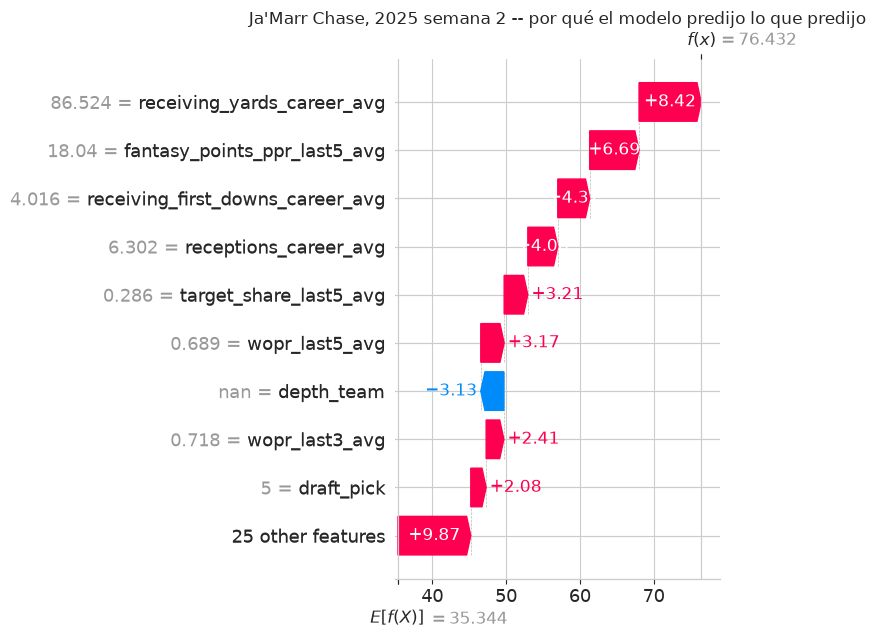

In [6]:
test_df = wr[test_mask].reset_index(drop=True)
chase = test_df[(test_df["player_display_name"] == "Ja'Marr Chase") & (test_df["season"] == 2025) & (test_df["week"] == 2)]
idx_chase = chase.index[0]
print(f"receiving_yards real esa semana: {chase['receiving_yards'].iloc[0]}, predicción del modelo: "
      f"{explicaciones['receiving_yards'][idx_chase].values.sum() + explicaciones['receiving_yards'][idx_chase].base_values:.1f}")

fig = plt.figure(figsize=(8, 5))
shap.plots.waterfall(explicaciones["receiving_yards"][int(idx_chase)], show=False)
plt.title("Ja'Marr Chase, 2025 semana 2 -- por qué el modelo predijo lo que predijo")
plt.tight_layout()
plt.show()

El modelo predijo 76.4 yardas contra las 165 reales — se queda corto, y de mucho, justo en la
semana más grande de Chase en todo 2025. No es un caso elegido para que salga bien: es honesto
mostrar también dónde falla. El `waterfall` muestra qué empujó la predicción hacia arriba (su
`target_share`/`wopr` recientes, `depth_team`) pero ninguna variable disponible anticipaba que esa
semana en particular sería un caso extremo — coincide con el patrón ya visto en
`13_comparacion_modelos.ipynb` (el modelo subestima sistemáticamente el cuartil de mayor volumen).
La sección 5 confirma si esto es la excepción o la regla.

## 5. Predicho vs. real, y los 5 peores errores — ¿hay un sesgo sistemático?

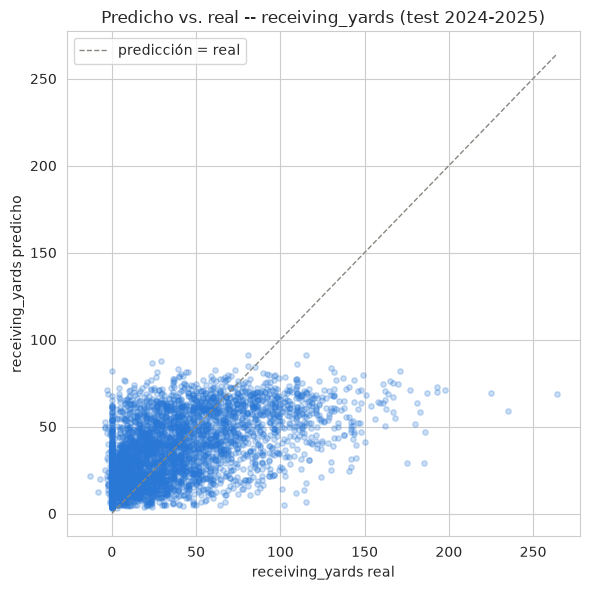

In [7]:
pred_yardas_test = MODELOS["receiving_yards"].predict(X[test_mask])
real_yardas_test = wr["receiving_yards"][test_mask].to_numpy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(real_yardas_test, pred_yardas_test, alpha=0.25, s=15, color=AZUL)
lim = max(real_yardas_test.max(), pred_yardas_test.max())
ax.plot([0, lim], [0, lim], color=GRIS, linestyle="--", linewidth=1, label="predicción = real")
ax.set_xlabel("receiving_yards real")
ax.set_ylabel("receiving_yards predicho")
ax.set_title("Predicho vs. real -- receiving_yards (test 2024-2025)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
test_df_yardas = wr[test_mask].copy()
test_df_yardas["pred"] = pred_yardas_test
test_df_yardas["error"] = test_df_yardas["pred"] - test_df_yardas["receiving_yards"]
peores = test_df_yardas.reindex(test_df_yardas["error"].abs().sort_values(ascending=False).index).head(5)
peores[["player_display_name", "season", "week", "receiving_yards", "pred", "error"]]

,player_display_name,season,week,receiving_yards,pred,error
19288,Ja'Marr Chase,2024,10,264,68.701027,-195.298973
18237,Jerry Jeudy,2024,13,235,59.042542,-175.957458
21487,Michael Wilson,2025,11,185,29.057470,-155.942530
22422,Puka Nacua,2025,16,225,69.136429,-155.863571
17290,Jauan Jennings,2024,3,175,28.885481,-146.114519


**Los 5 peores errores son los 5 subestimados, y todos son semanas boom reales** (Chase 264 vs.
68.7; Jeudy 235 vs. 59.0; Wilson 185 vs. 29.1; Nacua 225 vs. 69.1; Jennings 175 vs. 28.9) — ninguno
es una sobreestimación. Confirma, con el error individual más grande posible, exactamente el mismo
patrón que ya mostró el cuartil de mayor uso en `13_comparacion_modelos.ipynb` y el caso de Chase
arriba: el modelo tiende a quedarse corto en los extremos, no a exagerarlos. Es un sesgo real y
sistemático, no anecdótico — documentado con evidencia en 3 lugares distintos de esta fase, no uno
solo.

## Cierre

3 métodos de importancia distintos (permutación en Fase 4, importancia nativa de árbol en
`13_comparacion_modelos.ipynb`, y SHAP aquí) apuntan a las mismas variables como las más
influyentes — la señal es real, no un artefacto de un solo método. El caso de `receiving_tds`
deja documentada una lección concreta sobre respetar las suposiciones de un modelo: un enlace
logarítmico se lee en términos multiplicativos, no aditivos. Y los 3 targets con árboles de
predicción comparten el mismo sesgo honesto: subestiman las semanas boom más que sobreestiman las
malas — vale la pena tenerlo en cuenta para cualquier uso del modelo en piso/techo (Fase 5.1
pendiente) o en decisiones de alto impacto sobre un jugador en particular.

Siguiente: [`18_validacion_temporada_actual.ipynb`](18_validacion_temporada_actual.ipynb).